In [4]:
from pyanfis.functions import Gauss

func = Gauss(1, 1)
print(func)
print(func(1))

Gauss(mean=1, std=1)
1.0


In [5]:
from pyanfis.functions import Universe

univ = Universe(
    minimum = 0,
    maximum = 10,
    config_functions = {
        "Small": {
            "type": "Gauss",
            "parameters": {
                "mean": 0,
                "std": 5
            }
        },
        "Medium": {
            "type": "Gauss",
            "parameters": {
                "mean": 5,
                "std": 5
            }
        },
        "Big": {
            "type": "Gauss",
            "parameters": {
                "mean": 10,
                "std": 5
            }
        }
    }
)

print(univ)
print(univ(1))

Universe(functions={'Small': Gauss(mean=0, std=5), 'Medium': Gauss(mean=5, std=5), 'Big': Gauss(mean=10, std=5)}, maximum=10, minimum=0)
{'Small': 0.9801986733067553, 'Medium': 0.7261490370736909, 'Big': 0.19789869908361465}


In [6]:
from pyanfis.antecedents import Antecedents

In [7]:
antecedents_config = {
    "Input 1" : {
        "minimum": 0,
        "maximum": 10,
        "config_functions": {
            "Small": {
                "type": "Gauss",
                "parameters": {
                    "mean": 0,
                    "std": 5
                }
            },
            "Medium": {
                "type": "Gauss",
                "parameters": {
                    "mean": 5,
                    "std": 5
                }
            },
            "Big": {
                "type": "Gauss",
                "parameters": {
                    "mean": 10,
                    "std": 5
                }
            }
        }
    },
    "Input 2" : {
        "minimum": 0,
        "maximum": 10,
        "config_functions": {
            "Small": {
                "type": "Gauss",
                "parameters": {
                    "mean": 0,
                    "std": 5
                }
            },
            "Medium": {
                "type": "Gauss",
                "parameters": {
                    "mean": 5,
                    "std": 5
                }
            },
            "Big": {
                "type": "Gauss",
                "parameters": {
                    "mean": 10,
                    "std": 5
                }
            }
        }
    }
}
ant = Antecedents(antecedents_config)
print(ant)
x = ant({"Input 1": 0, "Input 2": 5,})
print(x)

Antecedents(universes={'Input 1': Universe(functions={'Small': Gauss(mean=0, std=5), 'Medium': Gauss(mean=5, std=5), 'Big': Gauss(mean=10, std=5)}, maximum=10, minimum=0), 'Input 2': Universe(functions={'Small': Gauss(mean=0, std=5), 'Medium': Gauss(mean=5, std=5), 'Big': Gauss(mean=10, std=5)}, maximum=10, minimum=0)})
{'Input 1': {'Small': 1.0, 'Medium': 0.6065306597126334, 'Big': 0.1353352832366127}, 'Input 2': {'Small': 0.6065306597126334, 'Medium': 1.0, 'Big': 0.6065306597126334}}


In [8]:
consequents_config = {
    "Output 1" : {
        "minimum": 0,
        "maximum": 10,
        "config_functions": {
            "Small": {
                "type": "Gauss",
                "parameters": {
                    "mean": 0,
                    "std": 5
                }
            },
            "Medium": {
                "type": "Gauss",
                "parameters": {
                    "mean": 5,
                    "std": 5
                }
            },
            "Big": {
                "type": "Gauss",
                "parameters": {
                    "mean": 10,
                    "std": 5
                }
            }
        }
    },
    "Output 2" : {
        "minimum": 0,
        "maximum": 10,
        "config_functions": {
            "Small": {
                "type": "Gauss",
                "parameters": {
                    "mean": 0,
                    "std": 5
                }
            },
            "Medium": {
                "type": "Gauss",
                "parameters": {
                    "mean": 5,
                    "std": 5
                }
            },
            "Big": {
                "type": "Gauss",
                "parameters": {
                    "mean": 10,
                    "std": 5
                }
            }
        }
    }
}

In [9]:
from pyanfis.rules import RulesBase
rules = [
    "If Input 1 is Big and Input 2 is Small then Output 1 is Small and Output 2 is Big",
    "If Input 2 is Big and Input 1 is Small then Output 1 is Big and Output 2 is Small and Output 2 is Big",
    "If Input 2 is Big then Output 1 is Big and Output 1 is Small"
]

rb = RulesBase(
    rules_list=rules,
    config_antecedents=antecedents_config,
    config_consequents=consequents_config
)
print(rb)

RulesBase(rules={'Antecedents': {'Rule 0': (('Input 1', 'Big'), ('Input 2', 'Small')), 'Rule 1': (('Input 2', 'Big'), ('Input 1', 'Small')), 'Rule 2': (('Input 2', 'Big'),)}, 'Consequents': {'Output 1': {'Rule 0': ['Small'], 'Rule 1': ['Big'], 'Rule 2': ['Big', 'Small']}, 'Output 2': {'Rule 0': ['Big'], 'Rule 1': ['Small', 'Big']}}})


In [10]:
from pyanfis.rules import RulesNeuron
rn = RulesNeuron(intersection_type = "mamdani")
print(rn)
f = rn(x, rb.rules["Antecedents"])
print(f)

RulesNeuron(intersection=<function mamdani at 0x146cd0f40>)
{'Rule 0': 0.0820849986238988, 'Rule 1': 0.6065306597126334, 'Rule 2': 0.6065306597126334}


In [11]:
def normalize(rules):
    denominator = sum([
        number for number in rules.values()
    ])

    return {
        name: value / denominator
        for name, value
        in rules.items()
    }

In [12]:
normalize(f)

{'Rule 0': 0.06337893833303762,
 'Rule 1': 0.46831053083348123,
 'Rule 2': 0.46831053083348123}

In [13]:
from pyanfis.consequents.types.tsukamoto import Tsukamoto

In [14]:
consequent_rules = {'Rule 0': ['Small'], 'Rule 1': ['Big'], 'Rule 2': ['Big', 'Small']}

In [15]:
consequents_config = {
    "minimum": 0,
    "maximum": 10,
    "config_functions": {
        "Small": {
            "type": "Gauss",
            "parameters": {
                "mean": 0,
                "std": 5
            }
        },
        "Medium": {
            "type": "Gauss",
            "parameters": {
                "mean": 5,
                "std": 5
            }
        },
        "Big": {
            "type": "Gauss",
            "parameters": {
                "mean": 10,
                "std": 5
            }
        }
    }
}

In [16]:
tsuka = Tsukamoto(
    config_universe = consequents_config,
    consequent_rules = consequent_rules
)

In [17]:
tsuka({'Rule 0': 0.11920292202211756, 'Rule 1': 0.8807970779778824})

0.8548323395933967

In [18]:
import matplotlib.pyplot as plt

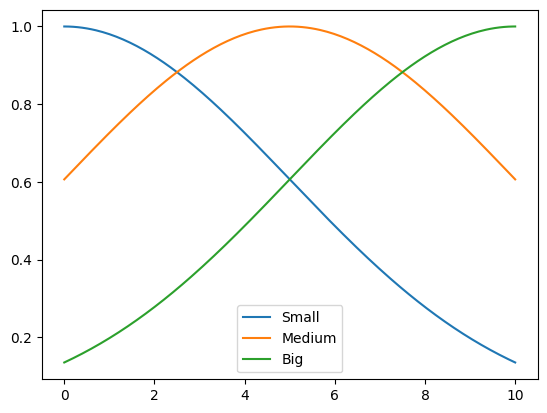

In [19]:
x = tsuka.universe_x_values
for name, value in tsuka.universe.functions.items():
    y = [value(i) for i in x]

    plt.plot(x, y, label=name)

plt.legend()
plt.show()

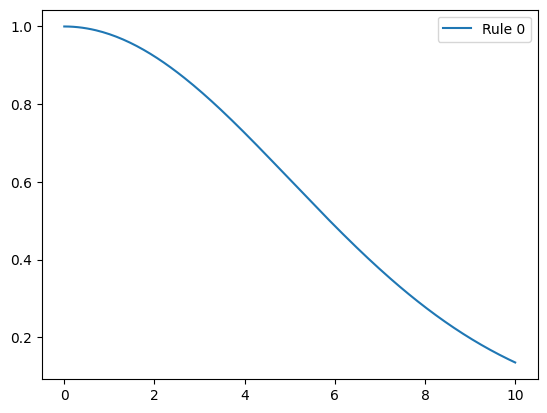

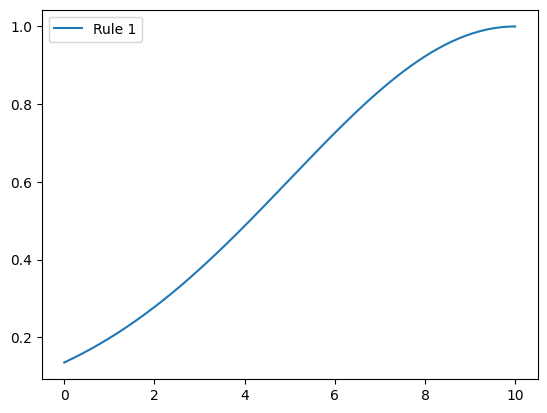

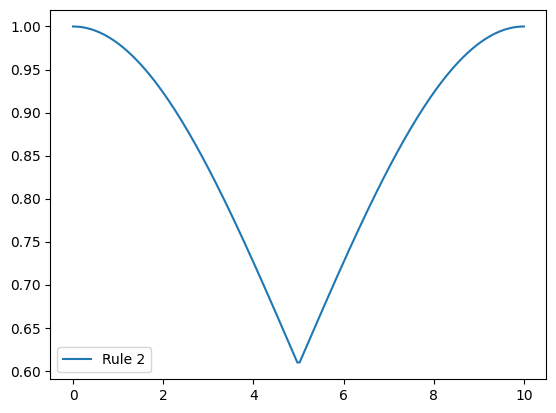

In [20]:
x = tsuka.universe_x_values
for rule, y in tsuka.precomputed_functions.items():
    plt.plot(x, y, label=rule)
    plt.legend()
    plt.show()


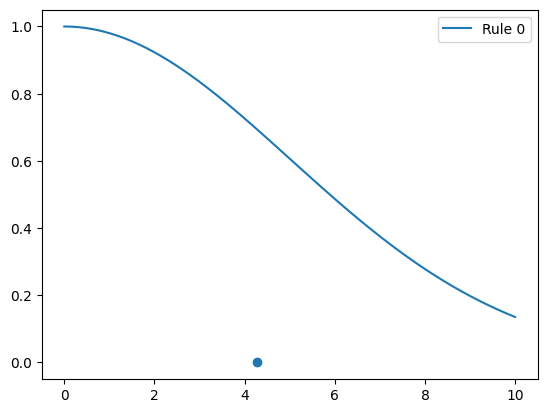

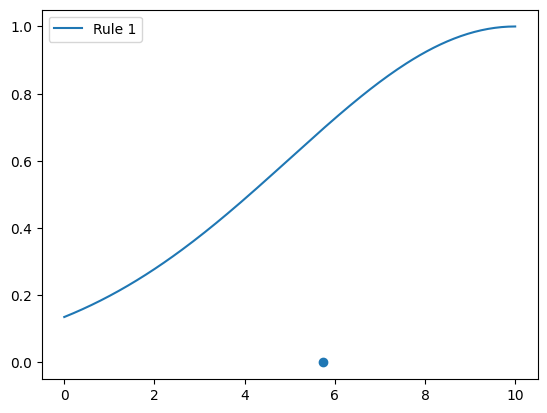

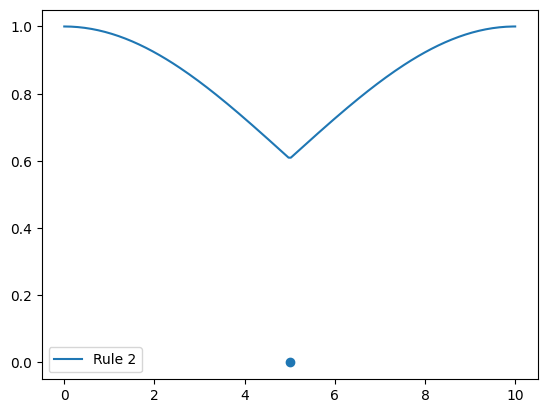

In [21]:
x = tsuka.universe_x_values
for rule, y in tsuka.precomputed_functions.items():
    out = tsuka(x_normalized = {rule: 0.5})
    plt.scatter(out, 0)
    plt.plot(x, y, label=rule)
    plt.legend()
    plt.show()


In [1]:
from pyanfis.anfis import ANFIS

In [2]:
config_antecedents = {
    "Input 1" : {
        "minimum": 0,
        "maximum": 10,
        "config_functions": {
            "Small": {
                "type": "LinearZ",
                "parameters": {
                    "shoulder": 0,
                    "foot": 10
                }
            },
            "Big": {
                "type": "LinearS",
                "parameters": {
                    "shoulder": 10,
                    "foot": 0
                }
            }
        }
    },
    "Input 2" : {
        "minimum": 0,
        "maximum": 10,
        "config_functions": {
            "Small": {
                "type": "LinearZ",
                "parameters": {
                    "shoulder": 0,
                    "foot": 8
                }
            },
            "Big": {
                "type": "LinearS",
                "parameters": {
                    "shoulder": 10,
                    "foot": 2
                }
            }
        }
    }
}

config_rules = {
    "intersection_type": "mamdani",
    "rules": [
        "If Input 1 is Small and Input 2 is Small then Output 1 is Small",
        "If Input 1 is Small and Input 2 is Big then Output 1 is Medium",
        "If Input 1 is Big and Input 2 is Small then Output 1 is Medium",
        "If Input 1 is Big and Input 2 is Big then Output 1 is Big"
    ]
}

config_consequents = {
    "Output 1": {
        "type": "Tsukamoto",
        "parameters": {
            "minimum": 0,
            "maximum": 20,
            "config_functions": {
                "Small": {
                    "type": "LinearZ",
                    "parameters": {
                        "shoulder": 0,
                        "foot": 10
                    }
                },
                "Medium": {
                    "type": "Gauss",
                    "parameters": {
                        "mean": 10,
                        "std": 5
                    }
                },
                "Big": {
                    "type": "LinearS",
                    "parameters": {
                        "shoulder": 20,
                        "foot": 10
                    }
                }
            }
        }
    }
}

In [3]:
anf = ANFIS(
    config_antecedents = config_antecedents,
    config_rules = config_rules,
    config_consequents = config_consequents,
)

In [4]:
output = anf({
    "Input 1": 0,
    "Input 2": 0
})

{'Input 1': {'Small': 1.0, 'Big': 0.0}, 'Input 2': {'Small': 1.0, 'Big': 0}}
{'Rule 0': 1.0, 'Rule 1': 0.0, 'Rule 2': 0.0, 'Rule 3': 0.0}
{'Rule 0': 1.0, 'Rule 1': 0.0, 'Rule 2': 0.0, 'Rule 3': 0.0}


In [5]:
output

{'Output 1': 3.3}

In [16]:
import matplotlib.pyplot as plt

In [29]:
len(y_values)

4

In [30]:
len(y_values)

4

In [31]:
neo_y_values = [max(col) for col in zip(*y_values)]

In [32]:
len(neo_y_values)

200

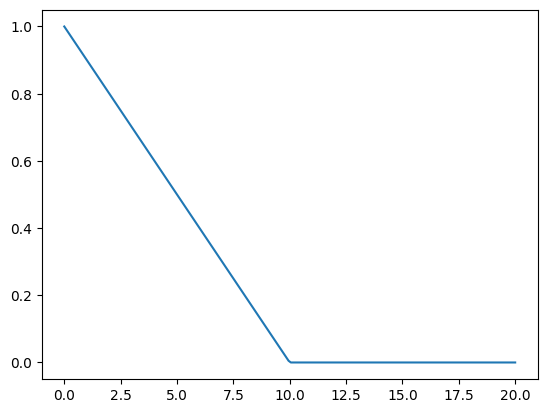

In [33]:
plt.plot(anf.consequents.universes["Output 1"].universe_x_values, neo_y_values)
plt.show()

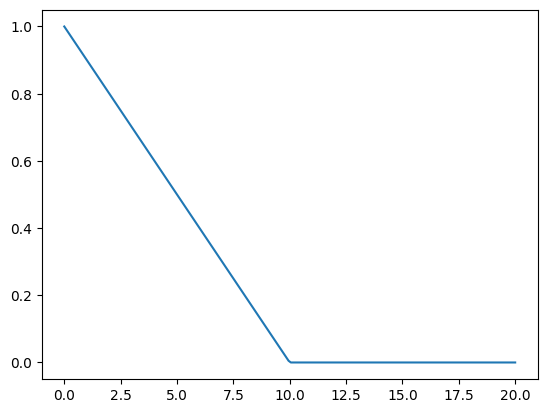

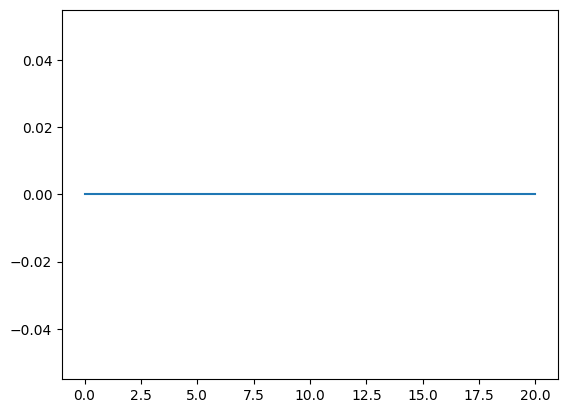

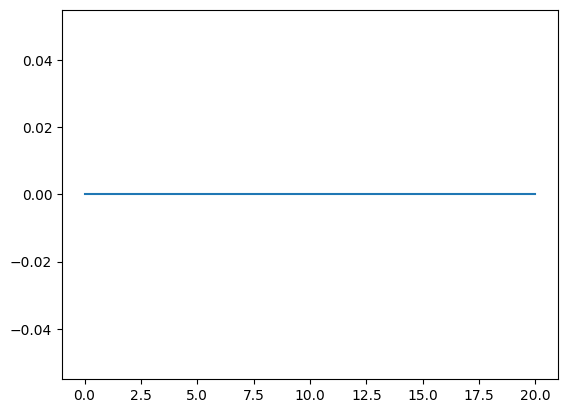

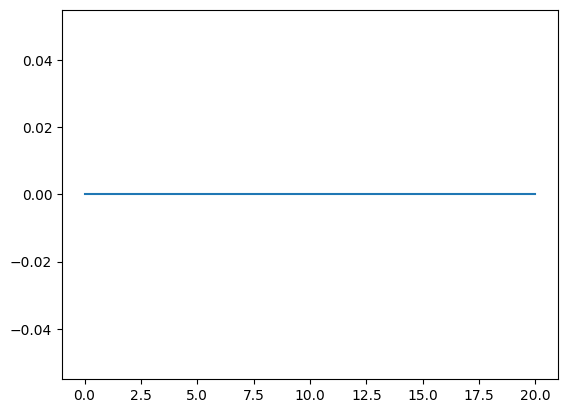

In [28]:
for i in y_values:
    
    plt.plot(anf.consequents.universes["Output 1"].universe_x_values, i)
    plt.show()